In [ ]:
import sys
from pathlib import Path

def _find_repo_root(start: Path, markers=(".git", "README.md")) -> Path:
    for candidate in (start, *start.parents):
        if any((candidate / m).exists() for m in markers):
            return candidate
    raise RuntimeError(f"Could not locate repo root above {start}")

REPO_ROOT = _find_repo_root(Path.cwd())
for _p in (REPO_ROOT / "algorithms", REPO_ROOT / "algorithms" / "nlp_sampling"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

from nlp_sampling import *

In [24]:
def g_circle(x):
    """
    Circle constraint function.
    feasible: x0^2 + x1^2 - 1 <= 0
    """
    return np.array([
        x[0] ** 2 + x[1] ** 2 - 1.0
    ])


def Jg_circle(x):
    """
    Jacobian of the circle constraint function.
    We need it for the Hit-and-Run algorithm to sample from the feasible region defined by the constraint.
    Returns the gradient of g_circle at point x.
    """
    return np.array([
        [2.0 * x[0], 2.0 * x[1]]
    ])


def f_zero(x):
    """
    Objective function (zero function).
    We don't have a specific objective to optimize, we just want to sample from the feasible region defined by the constraint.
    """
    # return 0.0
    
    # l2 norm near [-0.5, -0.5]
    return np.linalg.norm(x - np.array([-0.5, -0.5]))

def f_perimeter(x):
    """
    Objective function (perimeter of the circle).
    We want to sample from the feasible region defined by the constraint and maximize the perimeter of the circle.
    """
    return -2.0 * np.pi * np.sqrt(x[0] ** 2 + x[1] ** 2)


x0 = np.array([0.0, 0.0])
lower = np.array([-1.2, -1.2])
upper = np.array([1.2, 1.2])

options = NHROptions(
    num_samples=2000,
    burn_in=1,
    thinning=1,
    delta_max=0.5,
    random_seed=1,
    verbose=True,
)

samples, diagnostics = nhr_sample(
    x0=x0,
    g=g_circle,
    Jg=Jg_circle,
    f=f_zero,
    lower=lower,
    upper=upper,
    options=options,
)

step 00000/2001 | samples 00000/2000 | last: mh_accept
step 00200/2001 | samples 00200/2000 | last: mh_accept
step 00400/2001 | samples 00400/2000 | last: mh_accept
step 00600/2001 | samples 00600/2000 | last: mh_accept
step 00800/2001 | samples 00800/2000 | last: mh_accept
step 01000/2001 | samples 01000/2000 | last: mh_accept
step 01200/2001 | samples 01200/2000 | last: mh_accept
step 01400/2001 | samples 01400/2000 | last: mh_accept
step 01600/2001 | samples 01600/2000 | last: mh_accept
step 01800/2001 | samples 01800/2000 | last: mh_reject
step 02000/2001 | samples 02000/2000 | last: mh_accept


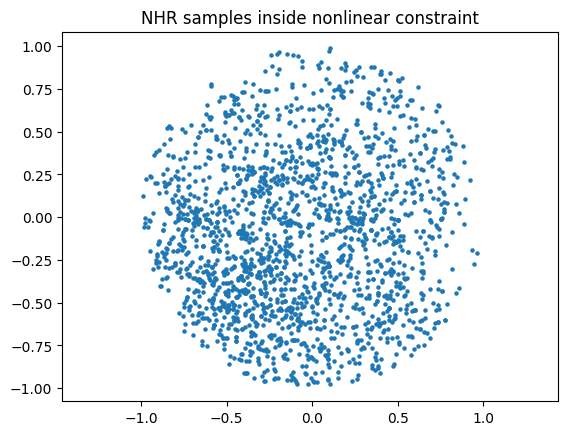

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(samples[:, 0], samples[:, 1], s=5)
plt.axis("equal")
plt.title("NHR samples inside nonlinear constraint")
plt.show()